# Fraud Detection on Elliptic Dataset

Fraud Detection is an important file to build a trusted and accessible financial ecosystem. When we impose restricted access to the financial system we can gain in security but loose in accesibility. And if we give free access, we expose the people to scams, money-laundring and other fraudulent activities. 

Building trusted and rigorus methods to detect fraud in financial activities is one of the most important things to have a healthy ecosystem. In this context Elliptic [[1]](#references) has emerged and focused on frauds with cryptocurrencies. 

Here we will analyze some methods in Network Analysis, TDA and ML to detect patterns of fraudulent activities. We will focus on the simple version of the Elliptic Data Set for a first version because of computational reasons. 

## Introduction

### What is Elliptic?

Elliptic is a cryptocurrency intelligence company [[2]](#references) focused on safeguarding cryptocurrency ecosystems from criminal activity. Cryptocurrency Ecosystems, such as Bitcoin, emerged with the objective of building a secure, distributed platform without without the need of central authorities to verify transactions [[3]](#references). 

This paradigm can help in building a digital ecosystem with less problems on restricted access to the financial system. Nevertheless, the pseudonymity of Bitcoin and the free access also can benefit fraudelent activities such. 

The blockchain has an architecture with miners and blocks which prevents fraudulent activities using Proof Of Work (POW) systems [[3]](#references). Nevertheless, preventing all the unethical uses of the platform is impossible. Thus, Elliptic aims to build tools for fraud-detection in the cryptocurrency ecosystems. 

With this objective, Elliptic has proposed a public data set *The Elliptic Data Set*, for researchers and  the ML community so we can learn and help on detecting fraudulent activities. This Data Set is a graph-structured DataSet. Let's see a little bit more on how is this dataset builded before diving in into Network Analysis. 

### Data Set Structure

This Data Set maps Bitcoin transactions to real entities belonging to licit versus ilicit ones. How the Bitcoin network is build it can bee a little tricky, I encourage to those who want to understand to read [[3]](#references). I will introduce, very, very briefly the concept of transaction:

<p style="padding:20px"><strong style="color:tomato">Transaction</strong>: a transaction is o movement of coins between one ore more addresses to one or more address. An address initialize a transaction proving their identity, telling the objective address and proving their 'coins' with previous transactions. A transaction, when is many-to-many can loose the information of who send what to whom. Thus, transactions, have information on the actual addresses and previous transactions.</p>

INTRODUCE IMAGE

*Nodes & Edges* --- In this dataset the transactions are grouped as nodes of a graph. Thus, an ilicit node in this dataset is a transaction which has a fraudulent activity of some address, and can group licit addrecess to an ilicit node. The DataSet uses this simplification to create a free-access workable and interesting data set. If the nodes are transactions, the edges are payment flows between transactions. Remember that past transactions aru used to proof future transactions. 

*Timestamps* --- The dataset is divided in 49 timestamps bla bla bla

*Features* ---

Now that we know more what we are working with, we can start exploring our graphs and analyzing patterns. 


<hr>

## EDA

In [21]:
# Load dependecies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys, os
sys.path.insert(0, os.path.abspath('..'))
from src.data.dataloader import DataLoaderFactory
from src.data.inspectionsstructured import *
from src.data.inspectionsnonstructured import *

In [2]:
# Load Data
loader = DataLoaderFactory()
zip_loader = loader.create('zip')

In [3]:
# Read Elliptic Data
# GED GraphFraudData object -- see data/graphstructure.py
GED = zip_loader.load_data('../data/raw/elliptic-data-set.zip', graph_structured=True) 

In [4]:
# Basic info of the graph 
structinspector = GraphInspector(GraphSummaryStrategy())
nostructinspector = DataInspector(SummaryStatsStrategy())

In [5]:
structinspector.run(GED)

= Graph Summary	========================================
  Nodes             : 203,769
  Edges             : 234,355
  Node features     : 167
  Unique classes    : 3  ['unknown', '2', '1']
  Proportion classes: 
                        unknown: 77.149 %
                        2: 20.621 %
                        1: 2.23 %

  Avg degree (undirected) : 2.30

-- Node features (head) --
         0    1         2         3         4          5         6    \
0  230425980    1 -0.171469 -0.184668 -1.201369  -0.121970 -0.043875   
1    5530458    1 -0.171484 -0.184668 -1.201369  -0.121970 -0.043875   
2  232022460    1 -0.172107 -0.184668 -1.201369  -0.121970 -0.043875   
3  232438397    1  0.163054  1.963790 -0.646376  12.409294 -0.063725   
4  230460314    1  1.011523 -0.081127 -1.201369   1.153668  0.333276   

        7          8         9    ...       157       158       159       160  \
0 -0.113002  -0.061584 -0.162097  ... -0.562153 -0.600999  1.461330  1.461369   
1 -0.113002  -0.06

= Node Feature Missing Values	====================
No missing values found.
= Class Distribution (class)	====================
          count    pct
class                 
1          4545   2.23
2         42019  20.62
unknown  157205  77.15


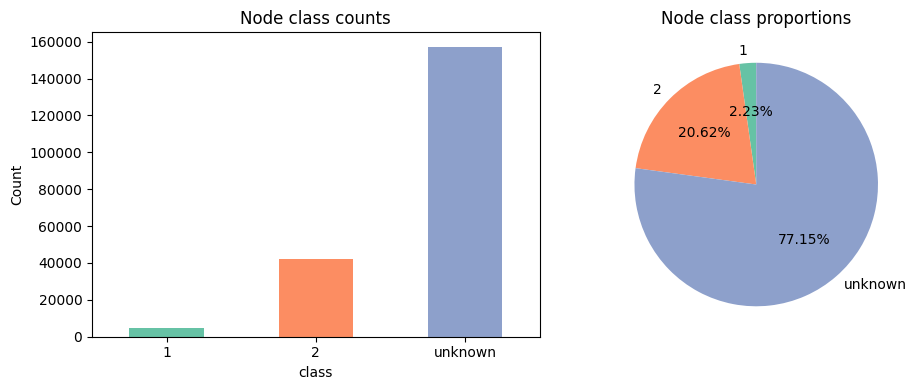

In [13]:
structinspector.set_strategy(NodeMissingValuesStrategy())
structinspector.run(GED)
structinspector.set_strategy(ClassDistributionStrategy())
structinspector.run(GED)

As we can see we have a completly unbalanced dataset. Our aim is to detect ilicit transactions which are class 1 (2.23%). We consider detecting a node as ilicit as a *positive*, and considering a node as *licit* or *unknown* as a negative. We want to minimize false negatives and priorize detecting positives. Meaning that we allow in some way acusing a licit user of fraudulent activities, but we don't want to miss any ilicit transactions.

We have 203,769 nodes and 234,355 edges, which should be grouped in 49 graphs. This numbers are quite reasonable with the avg degree of 2.30, we can understand this as most transactions have one in edge and one edge out. Is a quite disperse graph. 

Respect the variable features we have that var 0 and var 1 correspond to node index and timestamp respectively.Let's take a quick look on the rest of nodes features before going on the graph-structure analysis.

In [6]:
# Describe features nodes:
node_f = GED.node_features.iloc[:,2:]
nostructinspector.run(node_f)

= Shape	========================================
(203769, 165)

= Data types	========================================
2      float64
3      float64
4      float64
5      float64
6      float64
        ...   
162    float64
163    float64
164    float64
165    float64
166    float64
Length: 165, dtype: object

= Descriptive statistics	====================
                2             3             4             5             6    \
count  2.037690e+05  2.037690e+05  2.037690e+05  2.037690e+05  2.037690e+05   
mean   2.008513e-17  1.785345e-17  3.570689e-17  6.862418e-17  7.810883e-17   
std    1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00   
min   -1.729826e-01 -2.105526e-01 -1.756361e+00 -1.219696e-01 -6.372457e-02   
25%   -1.725317e-01 -1.803266e-01 -1.201369e+00 -1.219696e-01 -4.387455e-02   
50%   -1.692045e-01 -1.328975e-01  4.636092e-01 -1.219696e-01 -4.387455e-02   
75%   -1.318553e-01 -5.524241e-02  1.018602e+00 -1.219696e-01 -4.387455e-02   
max    7.16

Features have been cleaned and standarized, they are set to mean zero, variation 1, and there aren't missing values. As we said before, since the Elliptic Data Set is a prepeared data to learn on detecting fraud, we skip the work on cleaning data.

Nevertheless we have to analyze these features and see what we have. For this analysis we'll group by local features and neighborhood features, let's see a heatmap to visualize a little bit all the variables.

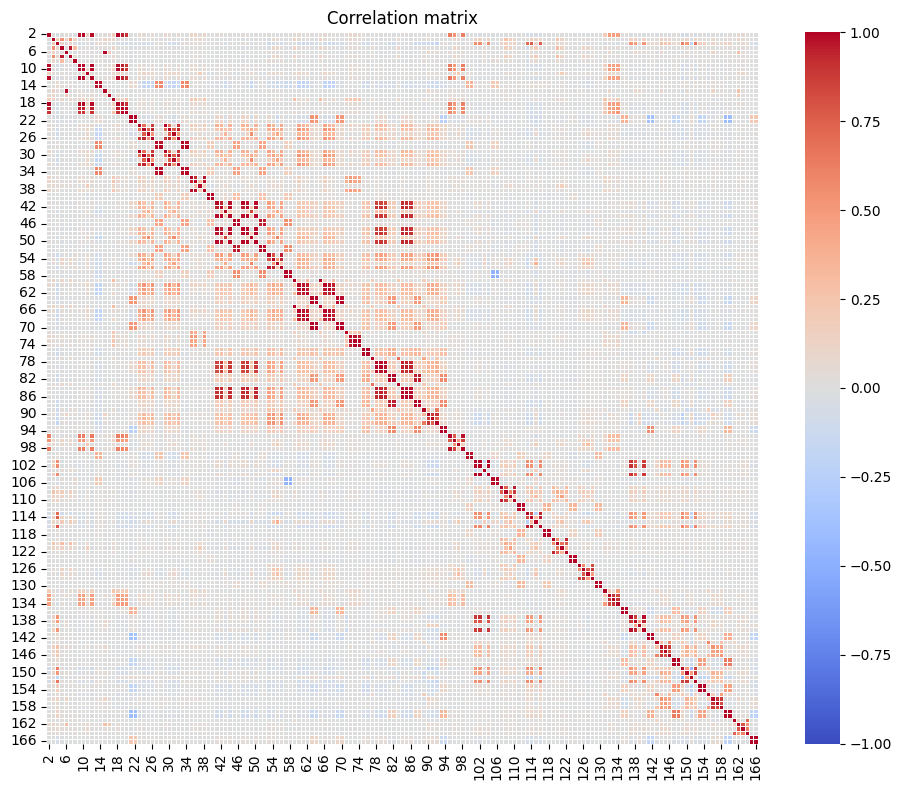

In [7]:
nostructinspector.set_strategy(CorrelationStrategy())
nostructinspector.run(node_f)

As we can see they are clearly separated between local (2-94) and neighborhood (95-166) features. Let's take a closer view of the hetmaps separating these variables.

In [8]:
local_node_f = node_f.iloc[:,:93]
neighborhood_node_f = node_f.iloc[:,93:]

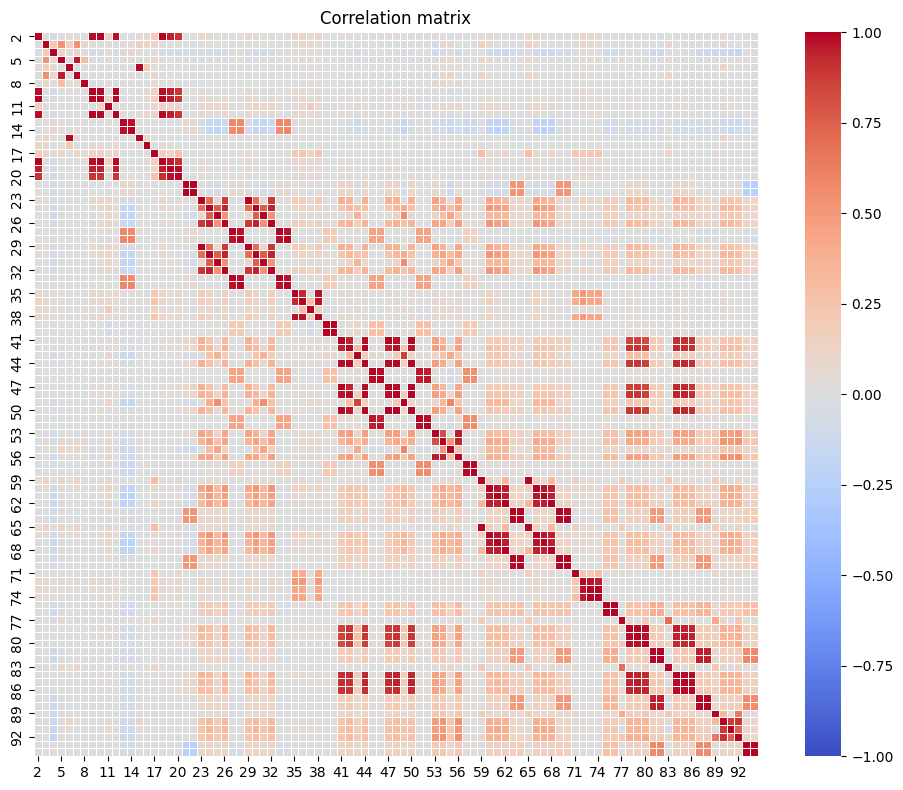

In [9]:
nostructinspector.run(local_node_f)

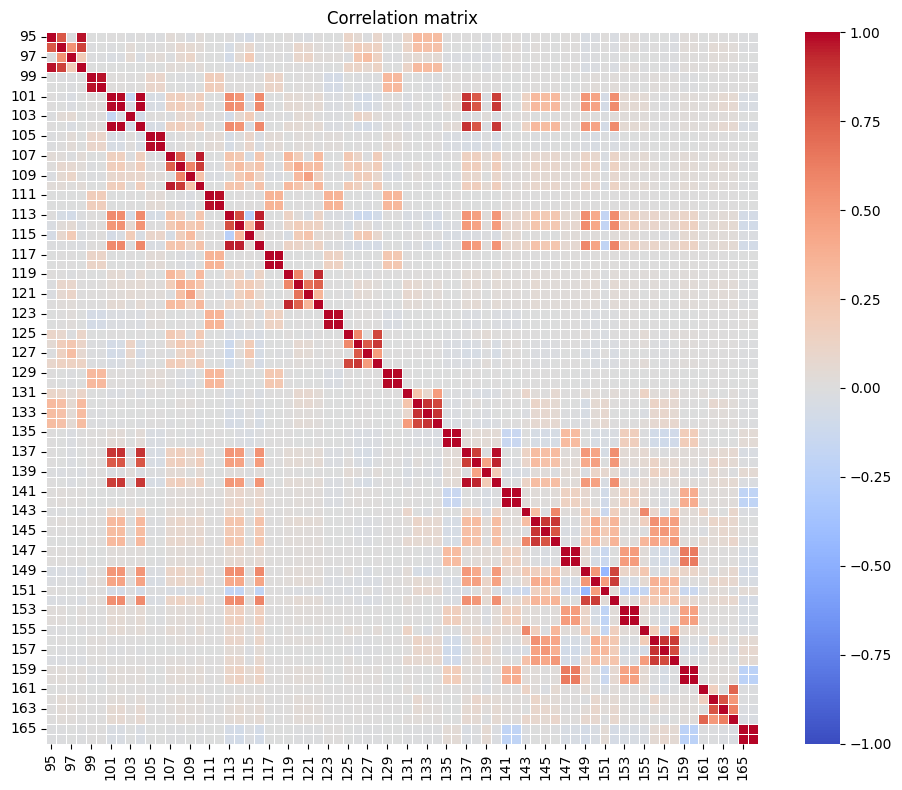

In [10]:
nostructinspector.run(neighborhood_node_f)

= Connected Components	========================================
  Number of components   : 49
  Largest component      : 7,880 nodes  (3.9%)
  Isolated nodes         : 0

  Size stats:
count      49.00
mean     4158.55
std      1592.47
min      1089.00
25%      2891.00
50%      4291.00
75%      5121.00
max      7880.00
Name: component_size, dtype: float64


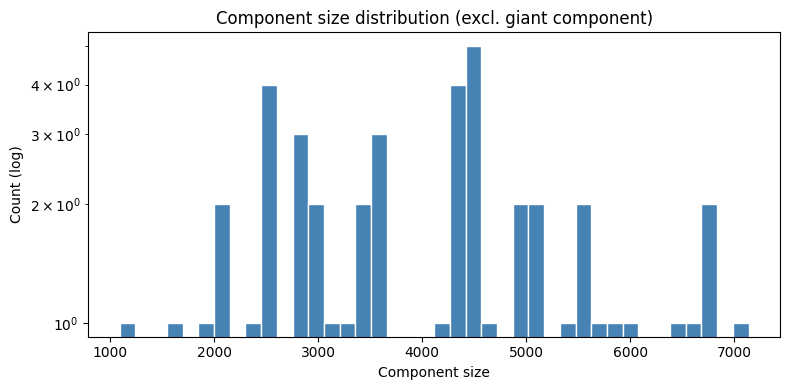

In [20]:
structinspector.set_strategy(ConnectedComponentsStrategy())
structinspector.run(GED)

---

### References

[1] [Elliptic, www.elliptic.co.](www.elliptic.co)

[2] [M. Weber, G. Domeniconi, J. Chen, D. K. I. Weidele, C. Bellei, T. Robinson, C. E. Leiserson, "Anti-Money Laundering in Bitcoin: Experimenting with Graph Convolutional Networks for Financial Forensics", KDD ’19 Workshop on Anomaly Detection in Finance, August 2019, Anchorage, AK, USA.](https://arxiv.org/pdf/1908.02591)

[3] [Blockchain: A Graph Primer. Cuneyt Gurcan Akcora, Yulia R. Gel, Murat Kantarcioglu, Dec 2022.](https://arxiv.org/pdf/1708.08749)